# RNN (Recurrent Neural Network)
순환신경망

## 자기 단계의 output을 다음 단계로도 보내고, 다시 자신의 input으로도 보냄

## 이 output : Hidden State (은닉상태)

## Simple RNN, LSTM(Long Short Term Memory), GRU(Gated Recurrent Unit)

## 텍스트 데이터 임베딩

# 실습

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

import tensorflow as tf
import keras
keras.utils.set_random_seed(SEED)

# 데이터 불러오기

In [ ]:
!pip install finance-datareader

In [3]:
import FinanceDataReader as fdr
data = fdr.DataReader('005930', '2020-12-07', '2026-06-30')

In [4]:
data.shape, type(data)

((1362, 6), pandas.core.frame.DataFrame)

In [5]:
data.head()

,Open,High,Low,Close,Volume,Change
Date,,,,,,
2020-12-07,72400,73500,71900,72900,28490496,0.019580
2020-12-08,72200,72900,71600,71700,25000338,-0.016461
2020-12-09,72100,73900,72000,73900,24077996,0.030683
2020-12-10,72700,73800,72500,72900,39882928,-0.013532
2020-12-11,73500,73800,73100,73400,18486672,0.006859


## EDA

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1362 entries, 2020-12-07 to 2026-06-30
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    1362 non-null   int64  
 1   High    1362 non-null   int64  
 2   Low     1362 non-null   int64  
 3   Close   1362 non-null   int64  
 4   Volume  1362 non-null   int64  
 5   Change  1362 non-null   float64
dtypes: float64(1), int64(5)
memory usage: 74.5 KB


In [7]:
data.describe()

,Open,High,Low,Close,Volume,Change
count,1362.000000,1362.000000,1362.000000,1362.000000,1.362000e+03,1362.000000
mean,84220.190896,85353.634361,83141.483113,84241.703377,1.885805e+07,0.001372
std,48743.871935,50456.411336,47213.282241,48958.121161,9.164033e+06,0.021994
min,50200.000000,51400.000000,49900.000000,49900.000000,5.767902e+06,-0.123055
25%,61600.000000,62200.000000,61000.000000,61700.000000,1.261891e+07,-0.010031
50%,71900.000000,72400.000000,71200.000000,71700.000000,1.638282e+07,0.000000
75%,80700.000000,81300.000000,80075.000000,80675.000000,2.260386e+07,0.010249
max,372500.000000,374500.000000,352000.000000,362500.000000,9.030618e+07,0.144086


### 시각화
line plot

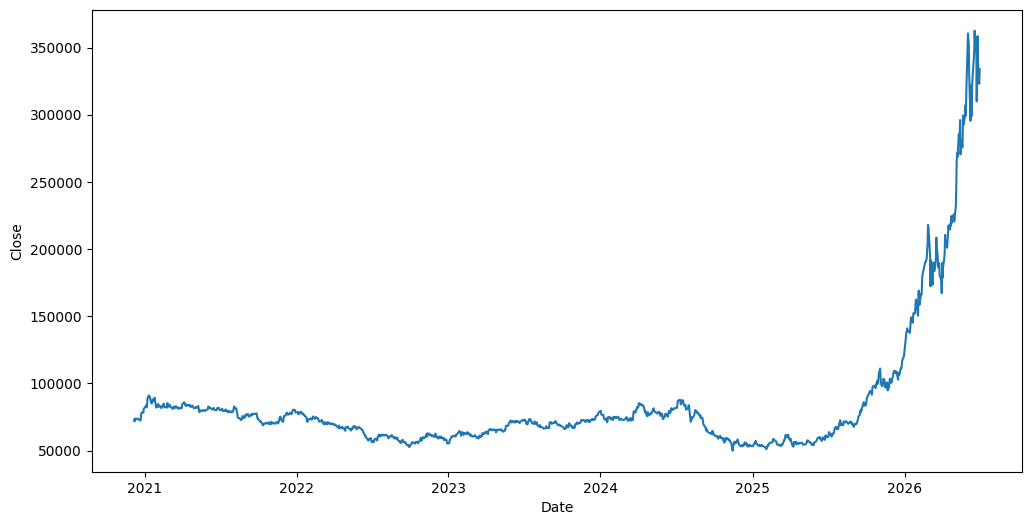

In [8]:
plt.figure(figsize=(12, 6))
sns.lineplot(x = data.index, y = data['Close'])
plt.show()

# 전처리

In [9]:
data['3MA'] = np.around(data['Close'].rolling(window=3).mean(), 0)       # 3일치의 평균을 냄
data['5MA'] = np.around(data['Close'].rolling(window=5).mean(), 0)       # 5일치의 평균을 냄

data.head()

,Open,High,Low,Close,Volume,Change,3MA,5MA
Date,,,,,,,,
2020-12-07,72400,73500,71900,72900,28490496,0.019580,NaN,NaN
2020-12-08,72200,72900,71600,71700,25000338,-0.016461,NaN,NaN
2020-12-09,72100,73900,72000,73900,24077996,0.030683,72833.0,NaN
2020-12-10,72700,73800,72500,72900,39882928,-0.013532,72833.0,NaN
2020-12-11,73500,73800,73100,73400,18486672,0.006859,73400.0,72960.0


여기서 3MA와 5MA의 NaN은 버려도 됨.

## 결측치 처리

In [10]:
data = data.dropna(axis=0)
data.head()

,Open,High,Low,Close,Volume,Change,3MA,5MA
Date,,,,,,,,
2020-12-11,73500,73800,73100,73400,18486672,0.006859,73400.0,72960.0
2020-12-14,73600,74500,73200,73800,21510415,0.005450,73367.0,73140.0
2020-12-15,73800,74100,73300,73800,20863671,0.000000,73667.0,73560.0
2020-12-16,74100,74500,73400,73800,17512081,0.000000,73800.0,73540.0
2020-12-17,73400,73700,72600,73300,24293214,-0.006775,73633.0,73620.0


# 데이터 분리

## train test 분리

In [11]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(data, test_size=0.2, shuffle=False, random_state=SEED)

## x y 분리

In [12]:
x_train = train.drop('Close', axis=1)
y_train = train['Close']

x_test = test.drop('Close', axis=1)
y_test = test['Close']

# Scaling
Min Max

In [13]:
from sklearn.preprocessing import MinMaxScaler

scaler_x = MinMaxScaler()
x_train_s = scaler_x.fit_transform(x_train)

In [14]:
y_train = y_train.to_numpy().reshape(-1, 1)

scaler_y = MinMaxScaler()
y_train_s = scaler_y.fit_transform(y_train)

y_train_s = y_train_s.reshape(-1)

## Sequence Dataset 으로 전환

In [15]:
def make_sequence_dataset(feature, label, window_size):
    feature_list = []
    label_list = []
    for i in range(len(feature) - window_size):
        feature_list.append(feature[i : i + window_size])
        label_list.append(label[i + window_size])
    return np.array(feature_list), np.array(label_list)

In [16]:
x_train_s, y_train_s = make_sequence_dataset(x_train_s, y_train_s, 20)

# 모델 정의

## Simple RNN

In [17]:
WINDOW_SIZE = 20
n_features = x_train_s.shape[2]

model = keras.Sequential([
    keras.Input(shape=(WINDOW_SIZE, n_features)),
    keras.layers.SimpleRNN(64, activation='tanh'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1)
])

## LSTM

In [18]:
WINDOW_SIZE = 20
n_features = x_train_s.shape[2]

model = keras.Sequential([
    keras.Input(shape=(WINDOW_SIZE, n_features)),
    keras.layers.LSTM(64),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1)
])

# 컴파일

In [19]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae'])

# Early Stopping

In [20]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True)

# 모델 학습

In [21]:
history = model.fit(
    x_train_s,
    y_train_s,
    epochs=200,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    shuffle=False)

Epoch 1/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0803 - mae: 0.1665 - val_loss: 0.0082 - val_mae: 0.0724
Epoch 2/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0027 - mae: 0.0413 - val_loss: 0.0103 - val_mae: 0.0842
Epoch 3/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0030 - mae: 0.0435 - val_loss: 0.0118 - val_mae: 0.0913
Epoch 4/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0031 - mae: 0.0443 - val_loss: 0.0117 - val_mae: 0.0911
Epoch 5/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0031 - mae: 0.0448 - val_loss: 0.0131 - val_mae: 0.0975
Epoch 6/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0034 - mae: 0.0464 - val_loss: 0.0164 - val_mae: 0.1120
Epoch 7/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0042 - mae: 0.0530 - val_loss: 0.0156 - val_mae: 0.1080
Epoch 8/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0035 - mae: 0.0479 - val_loss: 0.0184 - val_mae: 0.1202
Epoch 9/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - lo

# 테스트

In [22]:
x_test_s = scaler_x.transform(x_test)

y_test_arr = y_test.to_numpy().reshape(-1, 1)
y_test_s = scaler_y.transform(y_test_arr)
y_test_s = y_test_s.reshape(-1)

x_test_seq, y_test_seq = make_sequence_dataset(
    x_test_s,
    y_test_s,
    WINDOW_SIZE
)

## 돌려보기

In [23]:
y_pred_s = model.predict(x_test_seq)
y_pred = scaler_y.inverse_transform(y_pred_s)

y_true = scaler_y.inverse_transform(
    y_test_seq.reshape(-1, 1)
)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


## 결과 그래프

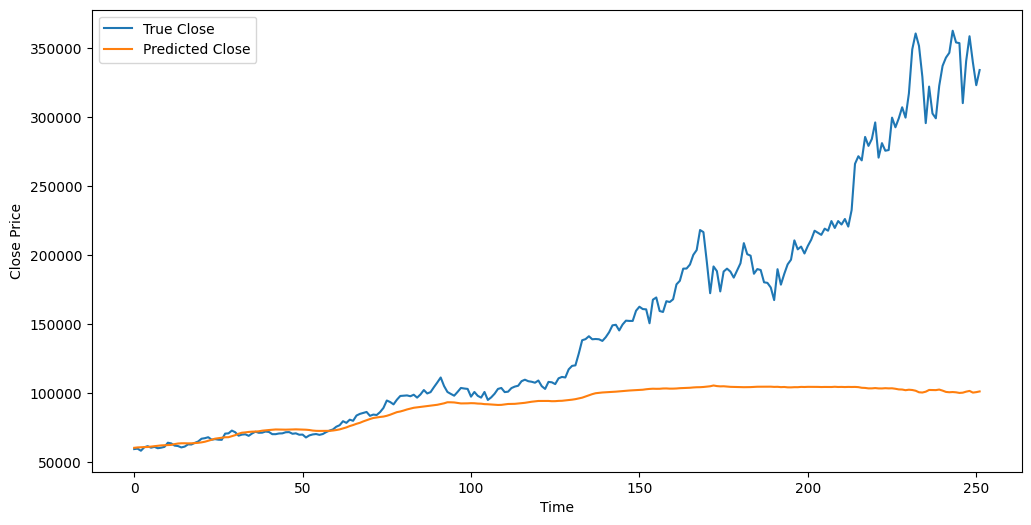

In [24]:
plt.figure(figsize=(12, 6))
plt.plot(y_true, label='True Close')
plt.plot(y_pred, label='Predicted Close')
plt.xlabel('Time')
plt.ylabel('Close Price')
plt.legend()
plt.show()